# OpenNTN PHY notebook

This notebook uses the modular files in `src/` and runs an SNR sweep with optional Monte Carlo averaging.

In [ ]:
import sys
import os

sys.path.append(os.path.abspath('.'))

%load_ext autoreload
%autoreload 2

In [ ]:
import numpy as np

from src import (
    ActionConfig,
    SimulationConfig,
    OpenNTNPhyExecutor,
    run_snr_sweep,
    run_snr_sweep_mc,
    plot_results,
)

I0000 00:00:1774536172.922340  349257 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1774536173.176873  349257 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1774536174.127130  349257 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [ ]:
action_cfg = ActionConfig(
    modulation='16QAM',
    code_rate=0.5,
    power_boost_db=0.0,
)

sim_cfg = SimulationConfig(
    scenario='dur',
    channel_model_name='DenseUrban',
    perfect_csi=True,
    doppler_enabled=True,
    elevation_angle=50.0,
    carrier_frequency=2.0e9,
    batch_size=512,
    num_ut=1,
    num_ut_ant=1,
    num_bs_ant=1,
    num_ofdm_symbols=14,
    fft_size=256,
    subcarrier_spacing=15e3,
    cyclic_prefix_length=16,
    pilot_ofdm_symbol_indices=[2, 11],
)

action_cfg, sim_cfg

(ActionConfig(modulation='QPSK', code_rate=0.5, power_boost_db=0.0),
 SimulationConfig(scenario='dur', channel_model_name='DenseUrban', perfect_csi=True, doppler_enabled=True, elevation_angle=50.0, carrier_frequency=2000000000.0, batch_size=512, num_ut=1, num_ut_ant=1, num_bs_ant=1, num_ofdm_symbols=14, fft_size=256, subcarrier_spacing=15000.0, cyclic_prefix_length=16, pilot_ofdm_symbol_indices=[2, 11]))

In [4]:
executor = OpenNTNPhyExecutor(action_cfg=action_cfg, sim_cfg=sim_cfg)
executor

I0000 00:00:1774536197.659519  349257 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 20854 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4090, pci bus id: 0000:01:00.0, compute capability: 8.9
I0000 00:00:1774536200.345160  349257 cuda_solvers.cc:175] Creating GpuSolver handles for stream 0x3eea6630


In [5]:
snr_db_list = np.arange(-5, 21, 0.5)
snr_db_list[:10], snr_db_list[-1]

(array([-5. , -4.5, -4. , -3.5, -3. , -2.5, -2. , -1.5, -1. , -0.5]), 20.5)

## Single sweep
Use this for quick debugging.

In [6]:
results_single = run_snr_sweep(executor, snr_db_list, verbose=True)

SNR= -5.0 dB | BER=3.4558e-01 | BLER=1.0000e+00 | iSE=0.0000
SNR= -4.5 dB | BER=3.3678e-01 | BLER=1.0000e+00 | iSE=0.0000
SNR= -4.0 dB | BER=3.2711e-01 | BLER=1.0000e+00 | iSE=0.0000
SNR= -3.5 dB | BER=3.1857e-01 | BLER=1.0000e+00 | iSE=0.0000
SNR= -3.0 dB | BER=3.0609e-01 | BLER=1.0000e+00 | iSE=0.0000
SNR= -2.5 dB | BER=2.9517e-01 | BLER=1.0000e+00 | iSE=0.0000
SNR= -2.0 dB | BER=2.8347e-01 | BLER=1.0000e+00 | iSE=0.0000
SNR= -1.5 dB | BER=2.6981e-01 | BLER=1.0000e+00 | iSE=0.0000
SNR= -1.0 dB | BER=2.5543e-01 | BLER=1.0000e+00 | iSE=0.0000
SNR= -0.5 dB | BER=2.4114e-01 | BLER=1.0000e+00 | iSE=0.0000
SNR=  0.0 dB | BER=2.2121e-01 | BLER=1.0000e+00 | iSE=0.0000
SNR=  0.5 dB | BER=1.9982e-01 | BLER=1.0000e+00 | iSE=0.0000
SNR=  1.0 dB | BER=1.6957e-01 | BLER=1.0000e+00 | iSE=0.0000
SNR=  1.5 dB | BER=1.0750e-01 | BLER=1.0000e+00 | iSE=0.0000
SNR=  2.0 dB | BER=2.6838e-02 | BLER=5.8398e-01 | iSE=0.4160
SNR=  2.5 dB | BER=1.1686e-02 | BLER=1.0352e-01 | iSE=0.8965
SNR=  3.0 dB | BER=6.738

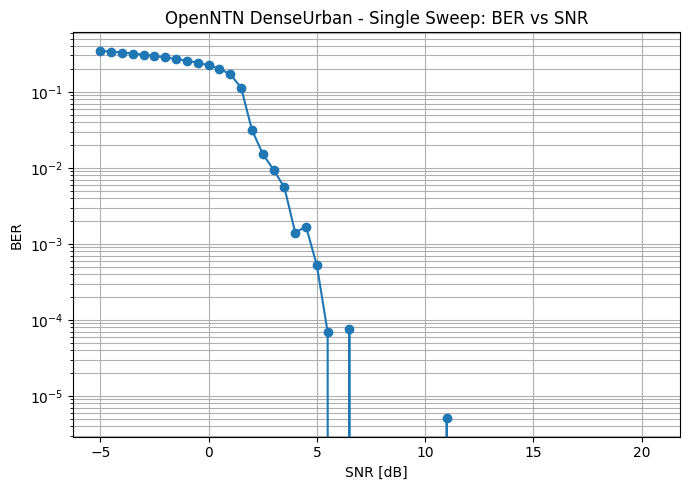

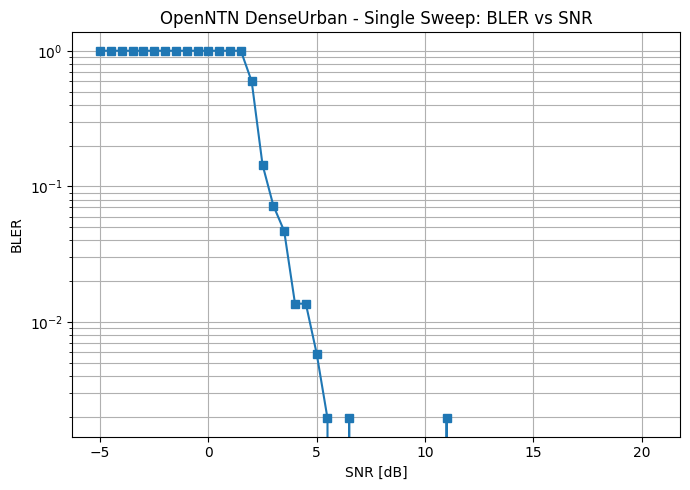

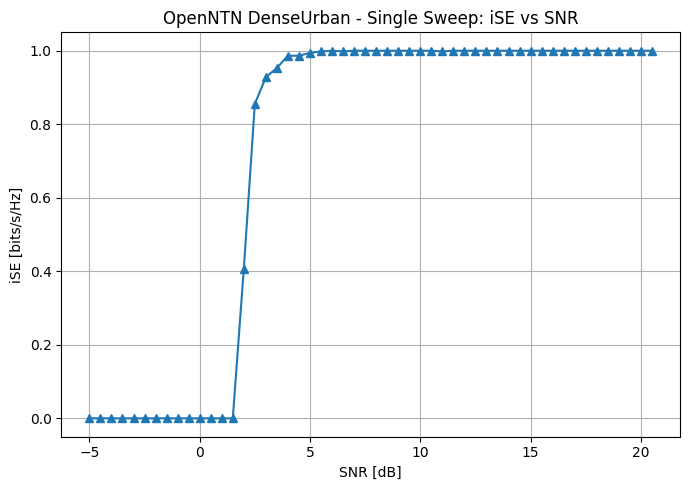

In [12]:
plot_results(results_single, title_prefix='OpenNTN DenseUrban - Single Sweep')

## Monte Carlo averaged sweep
Use this for smoother BER/BLER curves.

In [13]:
results_mc = run_snr_sweep_mc(executor, snr_db_list, num_iter=10, verbose=True)

Iteration 1/10
SNR= -5.0 dB | BER=3.4662e-01 | BLER=1.0000e+00 | iSE=0.0000
SNR= -4.5 dB | BER=3.3798e-01 | BLER=1.0000e+00 | iSE=0.0000
SNR= -4.0 dB | BER=3.2825e-01 | BLER=1.0000e+00 | iSE=0.0000
SNR= -3.5 dB | BER=3.1790e-01 | BLER=1.0000e+00 | iSE=0.0000
SNR= -3.0 dB | BER=3.0709e-01 | BLER=1.0000e+00 | iSE=0.0000
SNR= -2.5 dB | BER=2.9711e-01 | BLER=1.0000e+00 | iSE=0.0000
SNR= -2.0 dB | BER=2.8479e-01 | BLER=1.0000e+00 | iSE=0.0000
SNR= -1.5 dB | BER=2.7137e-01 | BLER=1.0000e+00 | iSE=0.0000
SNR= -1.0 dB | BER=2.5652e-01 | BLER=1.0000e+00 | iSE=0.0000
SNR= -0.5 dB | BER=2.4111e-01 | BLER=1.0000e+00 | iSE=0.0000
SNR=  0.0 dB | BER=2.2322e-01 | BLER=1.0000e+00 | iSE=0.0000
SNR=  0.5 dB | BER=2.0025e-01 | BLER=1.0000e+00 | iSE=0.0000
SNR=  1.0 dB | BER=1.7264e-01 | BLER=1.0000e+00 | iSE=0.0000
SNR=  1.5 dB | BER=1.1271e-01 | BLER=1.0000e+00 | iSE=0.0000
SNR=  2.0 dB | BER=3.3437e-02 | BLER=5.7812e-01 | iSE=0.4219
SNR=  2.5 dB | BER=1.8263e-02 | BLER=1.5430e-01 | iSE=0.8457
SNR=  3.0

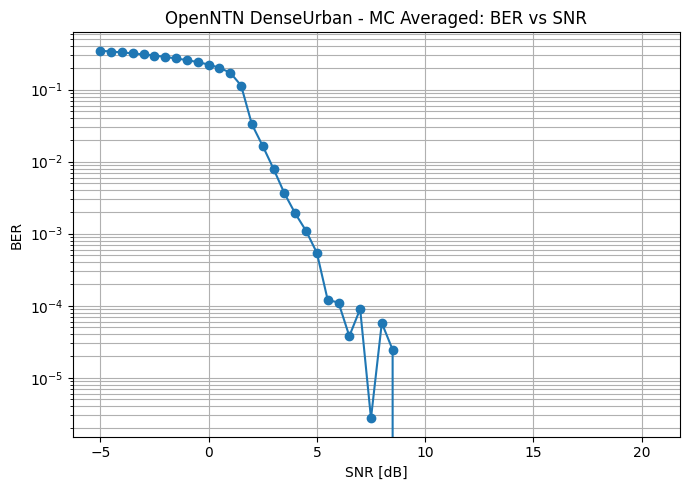

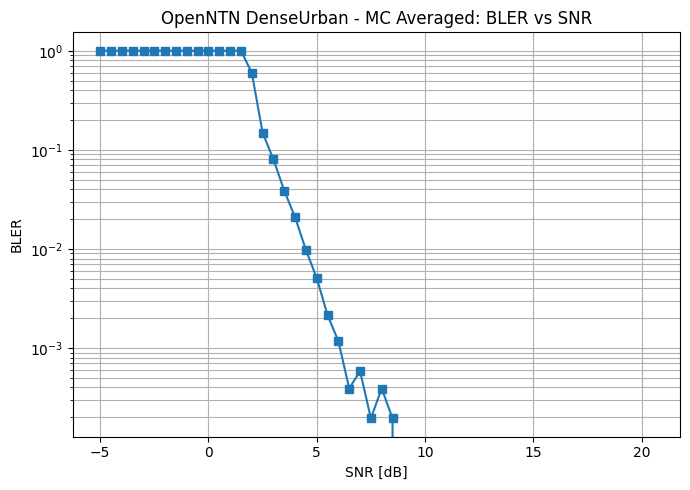

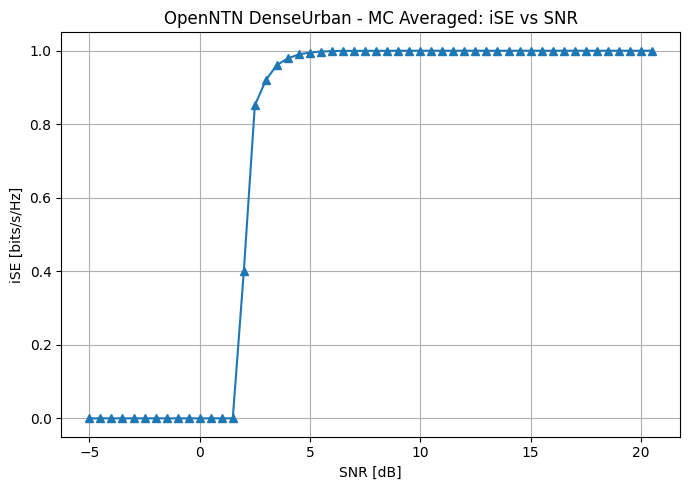

In [14]:
plot_results(results_mc, title_prefix='OpenNTN DenseUrban - MC Averaged')

In [15]:
# Optional: save results
np.savez('results_openntn_denseurban.npz', **results_mc)